<a href="https://colab.research.google.com/github/BenjaminBeltran27/GE2-Tarea1/blob/main/problema2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- TABLA DE ITERACIONES (CASO BASE) ---
Iter  | Ts (K)     | Tf (K)     | Re_D       | Nu_D     | h (W/m2K)  | R_cond (K/W) | R_conv (K/W)
1     | 743.000    | 528.000    | 59015.8   | 142.848   | 84.371      | 5.0691       | 11.60837
2     | 911.602    | 612.301    | 46135.4   | 126.251   | 83.961      | 5.0691       | 11.66509
3     | 912.488    | 612.744    | 46078.1   | 126.172   | 83.958      | 5.0691       | 11.66559
4     | 912.496    | 612.748    | 46077.6   | 126.172   | 83.958      | 5.0691       | 11.66560

--- TABLA COMPARATIVA FINAL ---
Escenario            | Ts (K)   | h      | R_cond   | R_conv   | R_tot    | Q (W)    | Iters
Caso base            | 912.496   | 83.96  | 5.069    | 11.666    | 16.735    | 51.390   | 4    
Mejora aerodinámica  | 878.773   | 100.48  | 5.069    | 9.748    | 14.817    | 58.043   | 4    
Cambio de material   | 1027.917   | 83.65  | 2.376    | 11.709    | 14.085    | 61.058   | 4    

--- ANÁLISIS COSTO-BENEFICIO ---
Mejora Aerodinámica:
  Redu

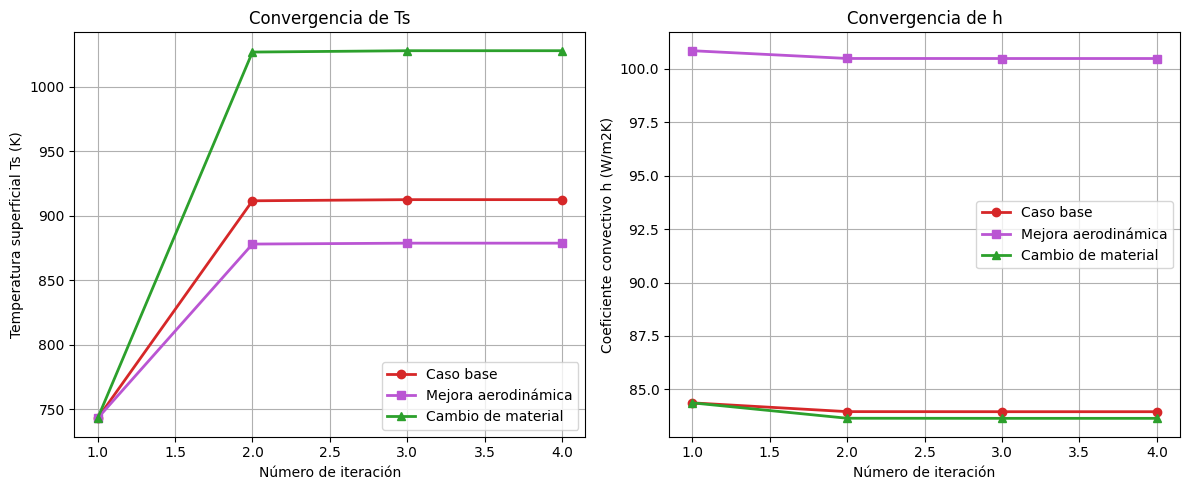

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. PARÁMETROS DE ENTRADA (Extraídos del Certamen 1)

L = 0.150        # Longitud del tramo (m)
r_i = 0.030      # Radio in (m)
r_o1 = 0.045     # Radio ex 1 (m)
r_o2 = 0.035     # Radio ex 2 (m)
T_h = 1173.0     # Temperatura caliente interna equivalente (K)
T_inf = 313.0    # Temperatura ambiente equivalente (K)
D = 2 * r_o2     # Diámetro característico en el extremo 2 (m)

# 2. PROPIEDADES DEL AIRE (Tabla para interpolación - Yunus Çengel, Tabla A-15)

# Columnas: T(K) [convertido de C+273.15], rho(kg/m3), mu(kg/m*s = Pa*s), k_f(W/mK), Pr
datos_aire = np.array([
    [0 + 273.15,    1.292,  1.729e-5, 0.02364, 0.7362],
    [50 + 273.15,   1.092,  1.963e-5, 0.02735, 0.7228],
    [100 + 273.15,  0.9458, 2.181e-5, 0.03095, 0.7111],
    [160 + 273.15,  0.8148, 2.420e-5, 0.03511, 0.7014],
    [200 + 273.15,  0.7459, 2.577e-5, 0.03779, 0.6974],
    [250 + 273.15,  0.6746, 2.760e-5, 0.04104, 0.6946],
    [300 + 273.15,  0.6158, 2.934e-5, 0.04418, 0.6935],
    [350 + 273.15,  0.5664, 3.101e-5, 0.04721, 0.6937],
    [400 + 273.15,  0.5243, 3.261e-5, 0.05015, 0.6948],
    [500 + 273.15,  0.4565, 3.563e-5, 0.05572, 0.6986],
    [600 + 273.15,  0.4042, 3.846e-5, 0.06093, 0.7037],
    [800 + 273.15,  0.3289, 4.362e-5, 0.07037, 0.7149],
    [1000 + 273.15, 0.2772, 4.826e-5, 0.07868, 0.7260]
])

# Funciones de interpolación lineal
f_rho = interp1d(datos_aire[:,0], datos_aire[:,1], kind='linear', fill_value="extrapolate")
f_mu  = interp1d(datos_aire[:,0], datos_aire[:,2], kind='linear', fill_value="extrapolate")
f_kf  = interp1d(datos_aire[:,0], datos_aire[:,3], kind='linear', fill_value="extrapolate")
f_Pr  = interp1d(datos_aire[:,0], datos_aire[:,4], kind='linear', fill_value="extrapolate")

# 3. FUNCIÓN DEL SOLVER ITERATIVO

def resolver_escenario(U, k_mat, nombre_escenario, guardar_historial=True): # Modificado a True por defecto
    # Tolerancia y valores iniciales
    tol = 1e-3
    error = 1.0
    iteracion = 0
    max_iter = 100

    # Suposición inicial de Ts
    Ts_guess = (T_h + T_inf) / 2.0

    historial = []

    while error > tol and iteracion < max_iter:
        iteracion += 1
        Ts_old = Ts_guess

        # 1. Temperatura de película
        T_f = (Ts_guess + T_inf) / 2.0

        # 2. Propiedades interpoladas
        rho = float(f_rho(T_f))
        mu = float(f_mu(T_f))
        k_f = float(f_kf(T_f))
        Pr = float(f_Pr(T_f))

        # 3. Números adimensionales y h
        Re_D = (rho * U * D) / mu
        Nu_D = 0.664 * (Re_D**0.5) * (Pr**(1/3))
        h = (Nu_D * k_f) / D

        # 4. Resistencias térmicas
        term1 = L / (2 * np.pi * k_mat * r_i * (r_o1 - r_o2))
        term2 = np.log(((r_o1 - r_i)*(r_o2 + r_i)) / ((r_o1 + r_i)*(r_o2 - r_i)))
        R_cond = term1 * term2

        R_conv = 1.0 / (h * np.pi * (r_o2**2 - r_i**2))
        R_tot = R_cond + R_conv

        # 5. Nueva temperatura superficial y flujo de calor
        Ts_new = T_inf + ((T_h - T_inf) / R_tot) * R_conv
        Q_dot = (T_h - T_inf) / R_tot

        # 6. Calcular error
        error = abs(Ts_new - Ts_old)
        Ts_guess = Ts_new

        if guardar_historial:
            historial.append({
                'iter': iteracion, 'Ts': Ts_old, 'Tf': T_f,
                'Re_D': Re_D, 'Nu_D': Nu_D, 'h': h, 'R_cond': R_cond, 'R_conv': R_conv
            })

    return {
        'nombre': nombre_escenario, 'Ts': Ts_guess, 'h': h,
        'R_cond': R_cond, 'R_conv': R_conv, 'R_tot': R_tot,
        'Q': Q_dot, 'iters': iteracion, 'historial': historial
    }

# 4.ESCENARIOS

escenarios = [
    {'nombre': 'Caso base', 'U': 35, 'k': 15},
    {'nombre': 'Mejora aerodinámica', 'U': 50, 'k': 15},
    {'nombre': 'Cambio de material', 'U': 35, 'k': 32}
]

resultados = []
for esc in escenarios:
    # AHORA GUARDAMOS HISTORIAL DE TODOS LOS ESCENARIOS
    res = resolver_escenario(esc['U'], esc['k'], esc['nombre'], guardar_historial=True)
    resultados.append(res)

# 5.RESULTADOS Y TABLAS

caso_base = resultados[0]

print("--- TABLA DE ITERACIONES (CASO BASE) ---")
print(f"{'Iter':<5} | {'Ts (K)':<10} | {'Tf (K)':<10} | {'Re_D':<10} | {'Nu_D':<8} | {'h (W/m2K)':<10} | {'R_cond (K/W)':<12} | {'R_conv (K/W)':<10}")
for h_data in caso_base['historial']:
    print(f"{h_data['iter']:<5} | {h_data['Ts']:.3f}    | {h_data['Tf']:.3f}    | {h_data['Re_D']:.1f}   | {h_data['Nu_D']:.3f}   | {h_data['h']:.3f}      | {h_data['R_cond']:.4f}       | {h_data['R_conv']:.5f}")

print("\n--- TABLA COMPARATIVA FINAL ---")
print(f"{'Escenario':<20} | {'Ts (K)':<8} | {'h':<6} | {'R_cond':<8} | {'R_conv':<8} | {'R_tot':<8} | {'Q (W)':<8} | {'Iters':<5}")
for r in resultados:
    print(f"{r['nombre']:<20} | {r['Ts']:.3f}   | {r['h']:.2f}  | {r['R_cond']:.3f}    | {r['R_conv']:.3f}    | {r['R_tot']:.3f}    | {r['Q']:.3f}   | {r['iters']:<5}")

# 6. ANÁLISIS COSTO-BENEFICIO

Ts_base = resultados[0]['Ts']
Ts_aero = resultados[1]['Ts']
Ts_mat = resultados[2]['Ts']

delta_Ts_aero = Ts_base - Ts_aero
delta_Ts_mat = Ts_base - Ts_mat

# Precios por evento
costo_aero = 300.0
costo_mat = 700.0

ind_aero = delta_Ts_aero / costo_aero
ind_mat = delta_Ts_mat / costo_mat

print("\n--- ANÁLISIS COSTO-BENEFICIO ---")
print(f"Mejora Aerodinámica:")
print(f"  Reducción de Ts = {delta_Ts_aero:.3f} K")
print(f"  Costo = USD ${costo_aero}")
print(f"  Indicador = {ind_aero:.4f} K/USD")

print(f"\nCambio de Material:")
print(f"  Reducción de Ts = {delta_Ts_mat:.3f} K")
print(f"  Costo = USD ${costo_mat}")
print(f"  Indicador = {ind_mat:.4f} K/USD")

# 7. GRÁFICOS DE CONVERGENCIA (TODOS LOS ESCENARIOS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))


colores = ['#d62728', '#ba55d3', '#2ca02c'] # Azul, Naranja, Verde
marcadores = ['o', 's', '^']

#  escenarios para graficarlos
for i, res in enumerate(resultados):
    iters = [d['iter'] for d in res['historial']]
    Ts_vals = [d['Ts'] for d in res['historial']]
    h_vals = [d['h'] for d in res['historial']]

    ax1.plot(iters, Ts_vals, marker=marcadores[i], color=colores[i], label=res['nombre'], linewidth=2)
    ax2.plot(iters, h_vals, marker=marcadores[i], color=colores[i], label=res['nombre'], linewidth=2)

ax1.set_xlabel('Número de iteración')
ax1.set_ylabel('Temperatura superficial Ts (K)')
ax1.set_title('Convergencia de Ts')
ax1.grid(True)
ax1.legend()

ax2.set_xlabel('Número de iteración')
ax2.set_ylabel('Coeficiente convectivo h (W/m2K)')
ax2.set_title('Convergencia de h')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.savefig('ts y h.png', dpi=300, bbox_inches='tight')
plt.show()